# Portfolio Project: Automobile Price Analysis and Regression Modeling 

---

# 02 — Data Cleaning & Feature Engineering
## Automobile Pricing Analytics

### Purpose
This notebook transforms the raw Automobile dataset into an analysis-ready table while preserving the original variables whenever possible.

The workflow builds directly on **Notebook 01 — Data Importing & Initial Understanding**, where the raw file was inspected without making substantive cleaning decisions.

### Objectives
1. Convert the raw missing-value marker (`?`) to standard missing values.
2. Treat missing values using transparent, variable-specific rules.
3. Correct data types so numerical variables are stored numerically.
4. Create a small set of interpretable derived features for later analysis.
5. Validate the cleaned dataset and export a reproducible analysis-ready file.

### Scope
This notebook focuses on **data quality and interpretable feature preparation**. Model-specific scaling and categorical encoding are intentionally deferred to the modeling stage so that preprocessing can be matched to the model and, where relevant, estimated using training data only.


## 1. Import libraries and locate the raw data

The raw file is reloaded here so that Notebook 02 can run independently. The same documented 26-column schema used in Notebook 01 is applied.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

candidate_paths = [
    Path("../data/auto.csv"),
    Path("data/auto.csv"),
    Path("auto.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "auto.csv was not found. Place it in ../data/, data/, or the current directory."
    )

print(f"Dataset location: {data_path.resolve()}")

Dataset location: /mnt/data/auto.csv


In [2]:
columns = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight",
    "engine-type", "num-of-cylinders", "engine-size", "fuel-system",
    "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
    "city-mpg", "highway-mpg", "price"
]

raw_df = pd.read_csv(data_path, header=None, names=columns)

assert raw_df.shape == (205, 26), f"Unexpected raw shape: {raw_df.shape}"
df = raw_df.copy()

print(f"Raw observations: {df.shape[0]:,}")
print(f"Raw variables: {df.shape[1]:,}")

Raw observations: 205
Raw variables: 26


## 2. Standardize missing-value representation

The source file uses `?` to represent unavailable values. These markers are first converted to `NaN`, which allows Pandas to identify and summarize missing observations consistently.

No imputation or row deletion occurs until the missingness pattern has been quantified.

In [3]:
df.replace("?", np.nan, inplace=True)

missing_before = (
    df.isna()
      .sum()
      .loc[lambda s: s > 0]
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

missing_before["percent_of_rows"] = (
    missing_before["missing_count"] / len(df) * 100
).round(2)

missing_before

,missing_count,percent_of_rows
normalized-losses,41,20.00
bore,4,1.95
stroke,4,1.95
price,4,1.95
num-of-doors,2,0.98
horsepower,2,0.98
peak-rpm,2,0.98


### Missingness assessment

Seven variables contain missing observations:

- `normalized-losses`
- `num-of-doors`
- `bore`
- `stroke`
- `horsepower`
- `peak-rpm`
- `price`

The treatment strategy is variable-specific rather than applying a single blanket rule:

- **Numerical predictors:** impute the sample mean, preserving observations in this relatively small dataset and maintaining continuity with the original project methodology.
- **`num-of-doors`:** impute the most frequent category (mode).
- **`price`:** remove observations with no target value because they cannot contribute to supervised price modeling or target-based analysis.

Mean imputation is pragmatic but not assumption-free: it can reduce variance and weaken natural relationships. This limitation should be kept in mind when interpreting downstream results, especially for `normalized-losses`, which has the largest amount of missingness.


## 3. Convert conceptually numerical columns

Several numerical fields were initially read as text because their columns contained `?`. After standardizing the missing markers, these columns can be safely converted to numeric types before calculating imputation values.

In [4]:
numeric_from_text = [
    "normalized-losses", "bore", "stroke",
    "horsepower", "peak-rpm", "price"
]

for column in numeric_from_text:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df[numeric_from_text].dtypes

normalized-losses    float64
bore                 float64
stroke               float64
horsepower           float64
peak-rpm             float64
price                float64
dtype: object

## 4. Impute missing predictor values

For the five numerical predictors below, missing values are replaced with the mean of the observed values in the same variable. The imputation statistics are recorded explicitly for reproducibility.

In [5]:
mean_impute_columns = [
    "normalized-losses",
    "bore",
    "stroke",
    "horsepower",
    "peak-rpm",
]

imputation_values = {}

for column in mean_impute_columns:
    mean_value = df[column].mean()
    imputation_values[column] = mean_value
    df[column] = df[column].fillna(mean_value)

pd.DataFrame.from_dict(
    imputation_values,
    orient="index",
    columns=["mean_used_for_imputation"]
).round(3)

,mean_used_for_imputation
normalized-losses,122.00
bore,3.33
stroke,3.25
horsepower,104.26
peak-rpm,"5,125.37"


## 5. Impute the categorical `num-of-doors` variable

The two missing `num-of-doors` observations are replaced with the modal category. Using the mode is appropriate here because the variable is categorical and `"four"` is the most frequently observed value in the sample.

In [6]:
door_counts = df["num-of-doors"].value_counts(dropna=False)
door_mode = df["num-of-doors"].mode().iat[0]

print("Observed door counts:")
print(door_counts)
print(f"\nMode used for imputation: {door_mode!r}")

df["num-of-doors"] = df["num-of-doors"].fillna(door_mode)

Observed door counts:
num-of-doors
four    114
two      89
NaN       2
Name: count, dtype: int64

Mode used for imputation: 'four'


## 6. Remove observations without the target variable

`price` is the outcome variable for the later regression analysis. Rows without an observed price cannot be used to estimate or evaluate a price model, so these observations are removed rather than imputed.

This preserves a clear distinction between imputing missing **predictors** and fabricating values for the **target**.

In [7]:
rows_before = len(df)
missing_price_rows = int(df["price"].isna().sum())

df = df.dropna(subset=["price"]).reset_index(drop=True)

print(f"Rows removed because price is missing: {missing_price_rows}")
print(f"Rows before target filtering: {rows_before}")
print(f"Rows after target filtering:  {len(df)}")

Rows removed because price is missing: 4
Rows before target filtering: 205
Rows after target filtering:  201


## 7. Correct and verify data types

After imputation and target filtering, variables that represent measured quantities are stored as numerical values. `normalized-losses` is retained as a numeric variable; `price`, engine measurements, horsepower, and RPM remain continuous numeric fields.

In [8]:
# Use integer storage where the cleaned values are integral; retain floats where
# measurement precision or mean imputation can introduce decimal values.
df["normalized-losses"] = df["normalized-losses"].astype(float)
df["bore"] = df["bore"].astype(float)
df["stroke"] = df["stroke"].astype(float)
df["horsepower"] = df["horsepower"].astype(float)
df["peak-rpm"] = df["peak-rpm"].astype(float)
df["price"] = df["price"].astype(float)

df.dtypes.to_frame("dtype")

,dtype
symboling,int64
normalized-losses,float64
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


## 8. Feature engineering: fuel-consumption units

The original dataset reports fuel economy in miles per gallon (`city-mpg` and `highway-mpg`). For interpretability in contexts that use litres per 100 kilometres, equivalent variables are created using:

**L/100 km = 235 / MPG**

The original MPG variables are retained rather than overwritten so later analyses can use either representation. Because the two representations are deterministic transformations of each other, they should not be entered into the same regression specification simultaneously.

In [9]:
df["city-L/100km"] = 235 / df["city-mpg"]
df["highway-L/100km"] = 235 / df["highway-mpg"]

df[
    ["city-mpg", "city-L/100km", "highway-mpg", "highway-L/100km"]
].head()

,city-mpg,city-L/100km,highway-mpg,highway-L/100km
0,21,11.19,27,8.70
1,21,11.19,27,8.70
2,19,12.37,26,9.04
3,24,9.79,30,7.83
4,18,13.06,22,10.68


## 9. Feature engineering: horsepower bands for descriptive analysis

We will group horsepower into three broad levels. But this is retained as an **interpretive EDA feature**, not as a replacement for continuous horsepower.

Keeping both versions is important:
- `horsepower` preserves the numerical information needed for regression.
- `horsepower-binned` provides a simple low/medium/high grouping for descriptive comparisons and visualizations.


In [10]:
horsepower_edges = np.linspace(
    df["horsepower"].min(),
    df["horsepower"].max(),
    4
)

horsepower_labels = ["Low", "Medium", "High"]

df["horsepower-binned"] = pd.cut(
    df["horsepower"],
    bins=horsepower_edges,
    labels=horsepower_labels,
    include_lowest=True
)

df[["horsepower", "horsepower-binned"]].head(10)

,horsepower,horsepower-binned
0,111.00,Low
1,111.00,Low
2,154.00,Medium
3,102.00,Low
4,115.00,Low
5,110.00,Low
6,110.00,Low
7,110.00,Low
8,140.00,Medium
9,101.00,Low


In [11]:
horsepower_bin_summary = (
    df["horsepower-binned"]
      .value_counts(sort=False)
      .rename("vehicle_count")
      .to_frame()
)

horsepower_bin_summary

,vehicle_count
horsepower-binned,
Low,153
Medium,43
High,5


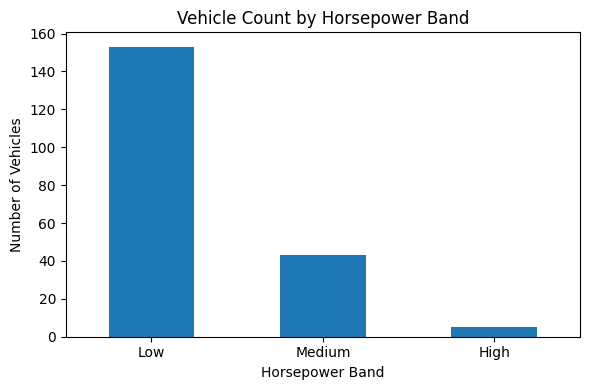

In [12]:
ax = horsepower_bin_summary.plot(
    kind="bar",
    legend=False,
    figsize=(6, 4)
)
ax.set_title("Vehicle Count by Horsepower Band")
ax.set_xlabel("Horsepower Band")
ax.set_ylabel("Number of Vehicles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Post-cleaning quality checks

The cleaned table should contain:
- 201 observations after removing four rows with missing `price`;
- no remaining missing values in the variables treated above;
- no exact duplicate records introduced by the cleaning process;
- valid positive prices;
- both the original continuous horsepower variable and the derived horsepower band.


In [13]:
quality_checks = {
    "rows": len(df),
    "columns": df.shape[1],
    "remaining_missing_values": int(df.isna().sum().sum()),
    "exact_duplicate_rows": int(df.duplicated().sum()),
    "non_positive_prices": int((df["price"] <= 0).sum()),
}

pd.Series(quality_checks, name="result").to_frame()

,result
rows,201
columns,29
remaining_missing_values,0
exact_duplicate_rows,0
non_positive_prices,0


In [14]:
assert len(df) == 201, f"Expected 201 rows after dropping missing prices; found {len(df)}."
assert df.isna().sum().sum() == 0, "Unexpected missing values remain after cleaning."
assert (df["price"] > 0).all(), "Price should be positive for all retained observations."
assert "horsepower-binned" in df.columns

print("All post-cleaning validation checks passed.")

All post-cleaning validation checks passed.


## 11. Cleaned-data overview

The summary below provides a final inspection before the cleaned dataset is passed to exploratory analysis.

In [15]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,highway-L/100km,horsepower-binned
0,3,122.00,alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111.00,"5,000.00",21,27,"13,495.00",11.19,8.70,Low
1,3,122.00,alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111.00,"5,000.00",21,27,"16,500.00",11.19,8.70,Low
2,1,122.00,alfa-romero,gas,std,two,hatchback,rwd,front,94.50,171.20,65.50,52.40,2823,ohcv,six,152,mpfi,2.68,3.47,9.00,154.00,"5,000.00",19,26,"16,500.00",12.37,9.04,Medium
3,2,164.00,audi,gas,std,four,sedan,fwd,front,99.80,176.60,66.20,54.30,2337,ohc,four,109,mpfi,3.19,3.40,10.00,102.00,"5,500.00",24,30,"13,950.00",9.79,7.83,Low
4,2,164.00,audi,gas,std,four,sedan,4wd,front,99.40,176.60,66.40,54.30,2824,ohc,five,136,mpfi,3.19,3.40,8.00,115.00,"5,500.00",18,22,"17,450.00",13.06,10.68,Low


In [16]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
symboling,201.00,NaN,NaN,NaN,0.84,1.25,-2.00,0.00,1.00,2.00,3.00
normalized-losses,201.00,NaN,NaN,NaN,122.00,32.00,65.00,101.00,122.00,137.00,256.00
make,201,22,toyota,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel-type,201,2,gas,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aspiration,201,2,std,165,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num-of-doors,201,2,four,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body-style,201,5,sedan,94,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drive-wheels,201,3,fwd,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine-location,201,2,front,198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheel-base,201.00,NaN,NaN,NaN,98.80,6.07,86.60,94.50,97.00,102.40,120.90


## 12. Export the analysis-ready dataset

The cleaned dataset is saved as `auto_cleaned.csv`. 

The index is excluded so that reloading the CSV does not create an artificial unnamed column.


In [17]:
if Path("data").exists():
    output_path = Path("data/auto_cleaned.csv")
elif Path("../data").exists():
    output_path = Path("../data/auto_cleaned.csv")
else:
    output_path = data_path.parent / "auto_cleaned.csv"

df.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path.resolve()}")
print(f"Final shape: {df.shape}")

Cleaned dataset saved to: /mnt/data/auto_cleaned.csv
Final shape: (201, 29)


## 13. Cleaning decisions and analytical implications

The final cleaning workflow makes a small number of explicit assumptions:

- Numerical predictor gaps are mean-imputed to preserve sample size.
- The categorical `num-of-doors` gaps are mode-imputed.
- Four observations without an observed `price` are excluded.
- Original measurement units are preserved, while L/100 km versions are added as supplementary variables.
- Horsepower bands are created only for descriptive interpretation; continuous horsepower remains available for regression.

These choices produce a transparent, reusable dataset while minimizing unnecessary transformations.

### Handoff to Notebook 03
**Notebook 03 — Exploratory Data Analysis** will use this cleaned dataset to investigate price distributions, relationships between automobile characteristics and price, differences across categorical groups, and the set of predictors that merit consideration in regression modeling.
